<a href="https://colab.research.google.com/github/MuhammadAjlal2004/A-Quantitative-Greenwashing-Index-for-the-Luxury-Sector/blob/main/SW(Data_Analysis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- INDUSTRY TOTALS (All Brands) ---
Total Sustainability Talk (C_Count): 458054
Total Greenwashing Scrutiny (G_Count): 7871
Global Imbalance Ratio: 1.72%
------------------------------------



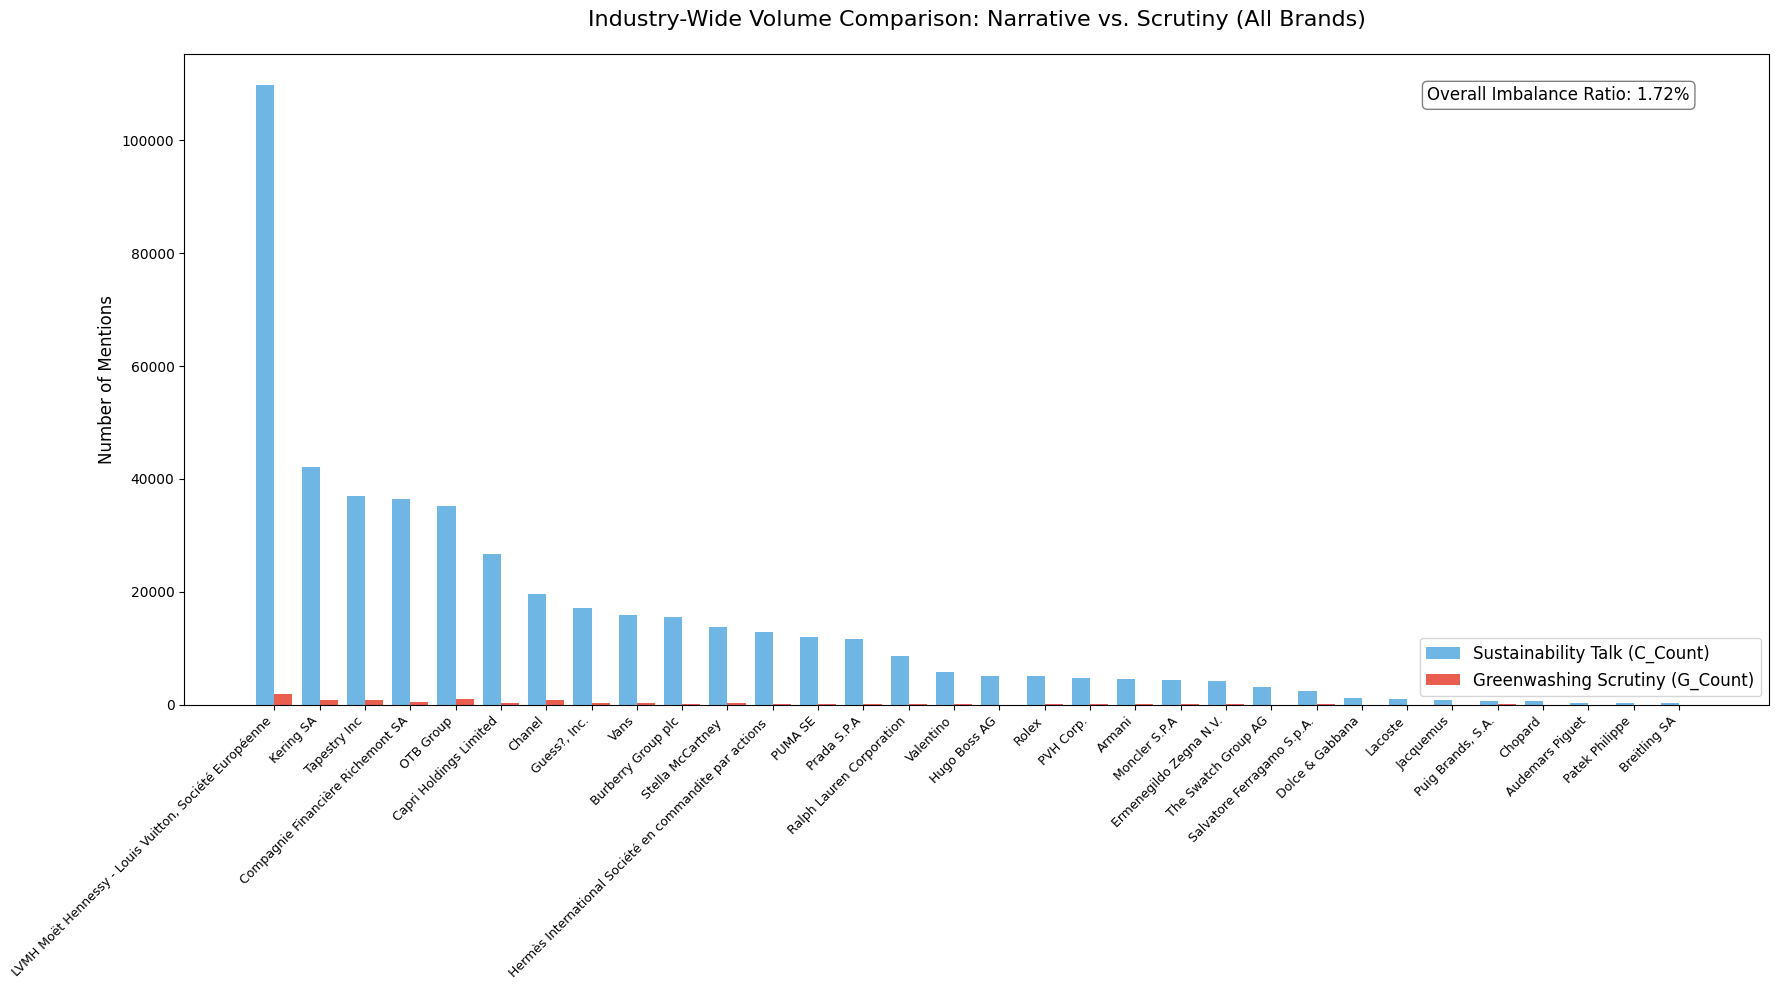

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_all = pd.read_excel('/content/SW_Analysis.xlsx')

# Data cleaning
df_all['G_Count'] = pd.to_numeric(df_all['G_Count'], errors='coerce').fillna(0)
df_all['C_Count'] = pd.to_numeric(df_all['C_Count'], errors='coerce').fillna(0)

# Calculating aggregate totals
total_c = df_all['C_Count'].sum()
total_g = df_all['G_Count'].sum()
imbalance_ratio = (total_g / total_c) * 100 if total_c > 0 else 0

print(f"--- INDUSTRY TOTALS (All Brands) ---")
print(f"Total Sustainability Talk (C_Count): {int(total_c)}")
print(f"Total Greenwashing Scrutiny (G_Count): {int(total_g)}")
print(f"Global Imbalance Ratio: {imbalance_ratio:.2f}%")
print("------------------------------------\n")

# Visualizing with Bar Chart
df_sorted = df_all.sort_values('C_Count', ascending=False)

plt.figure(figsize=(18, 10))
x = np.arange(len(df_sorted))
width = 0.4

plt.bar(x - width/2, df_sorted['C_Count'], width, label='Sustainability Talk (C_Count)', color='#3498DB', alpha=0.7)
plt.bar(x + width/2, df_sorted['G_Count'], width, label='Greenwashing Scrutiny (G_Count)', color='#E74C3C', alpha=0.9)
plt.xticks(x, df_sorted['Brand Name'], rotation=45, ha='right', fontsize=9)
plt.ylabel('Number of Mentions', fontsize=12)
plt.title('Industry-Wide Volume Comparison: Narrative vs. Scrutiny (All Brands)', fontsize=16, pad=20)
plt.legend(fontsize=12)


plt.text(0.95, 0.95, f'Overall Imbalance Ratio: {imbalance_ratio:.2f}%',
         transform=plt.gca().transAxes, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5), fontsize=12)

plt.tight_layout()
plt.savefig('Full_Industry_Volume.png', dpi=300)
plt.show()

In [ ]:
# Calculating the normalized greenwashing ratio

min_gw_ratio = df_all['Greenwashing Ratio'].min()
max_gw_ratio = df_all['Greenwashing Ratio'].max()
target_normalized_max = 100

if max_gw_ratio - min_gw_ratio > 0:
    df_all['Normalized_GW'] = ((df_all['Greenwashing Ratio'] - min_gw_ratio) /
                               (max_gw_ratio - min_gw_ratio)) * target_normalized_max
else:
    df_all['Normalized_GW'] = 0

display(df_all[['Brand Name', 'Greenwashing Ratio', 'Normalized_GW', 'CSA Score']].head())

,Brand Name,Greenwashing Ratio,Normalized_GW,CSA Score
0,"LVMH Moët Hennessy - Louis Vuitton, Société Eu...",0.017228,42.617272,62.0
1,Kering SA,0.019728,49.266685,78.0
2,Compagnie Financière Richemont SA,0.010147,23.782934,32.0
3,Burberry Group plc,0.011246,26.707045,45.0
4,Hermès International Société en commandite par...,0.007480,16.690567,64.0


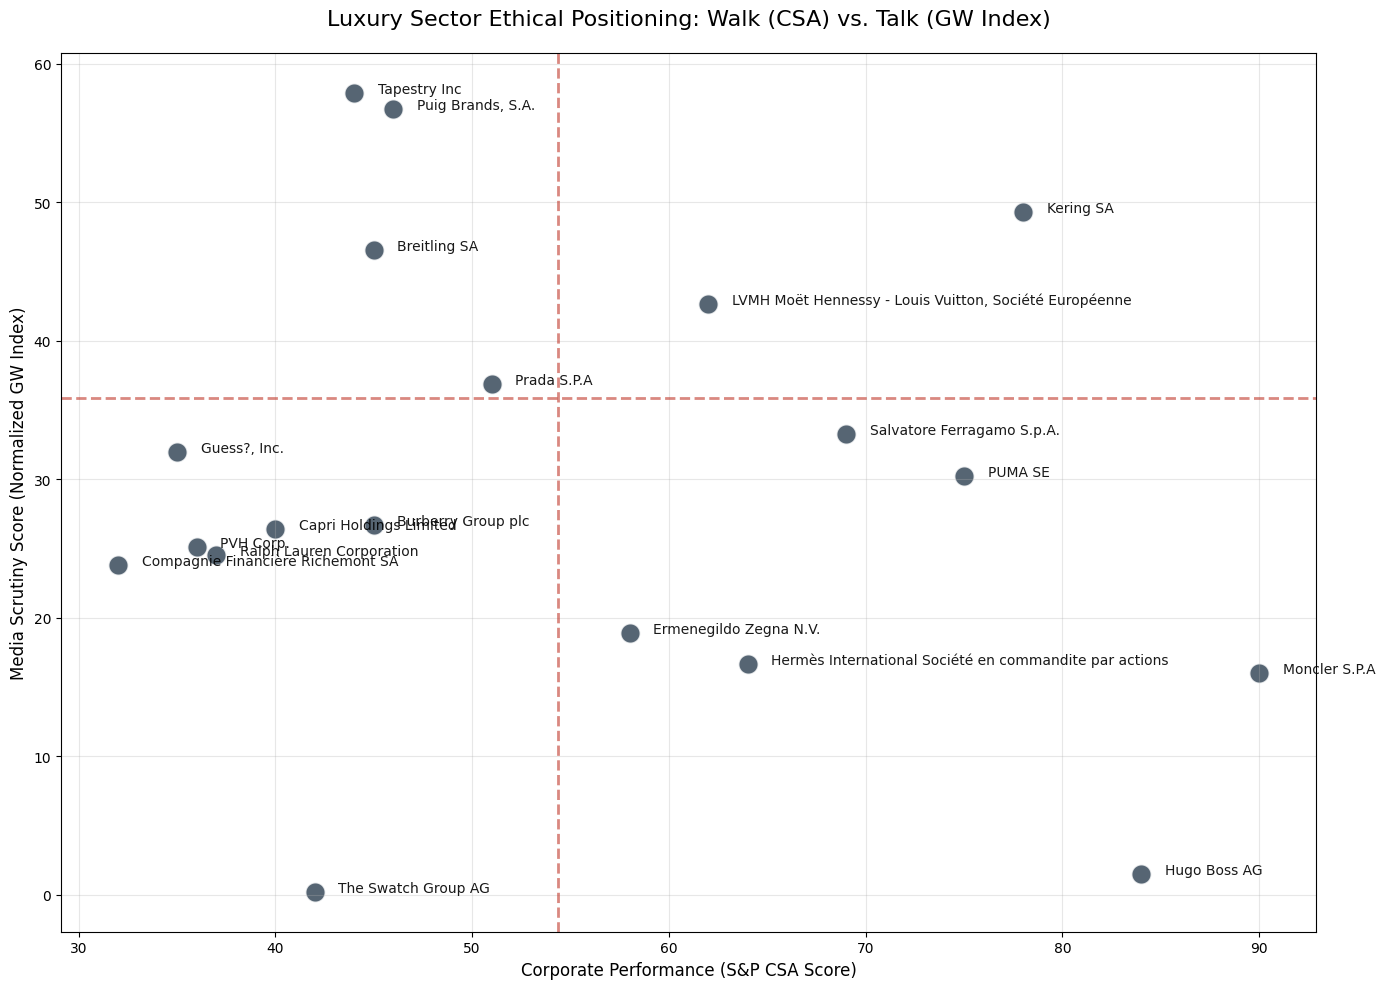

In [ ]:
# Creating a Quadrant map of the data

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.scatterplot(data=df_all, x='CSA Score', y='Normalized_GW', s=200, color='#2C3E50', alpha=0.8)
plt.axvline(df_all['CSA Score'].mean(), color='#C0392B', linestyle='--', alpha=0.6, linewidth=2)
plt.axhline(df_all['Normalized_GW'].mean(), color='#C0392B', linestyle='--', alpha=0.6, linewidth=2)

for i in range(df_all.shape[0]):
    plt.text(df_all['CSA Score'].iloc[i] + 1.2,
             df_all['Normalized_GW'].iloc[i],
             df_all['Brand Name'].iloc[i],
             fontsize=10,
             alpha=0.9)

plt.title('Luxury Sector Ethical Positioning: Walk (CSA) vs. Talk (GW Index)', fontsize=16, pad=20)
plt.xlabel('Corporate Performance (S&P CSA Score)', fontsize=12)
plt.ylabel('Media Scrutiny Score (Normalized GW Index)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Chart2_Quadrants_Clean.png', dpi=300)
plt.show()

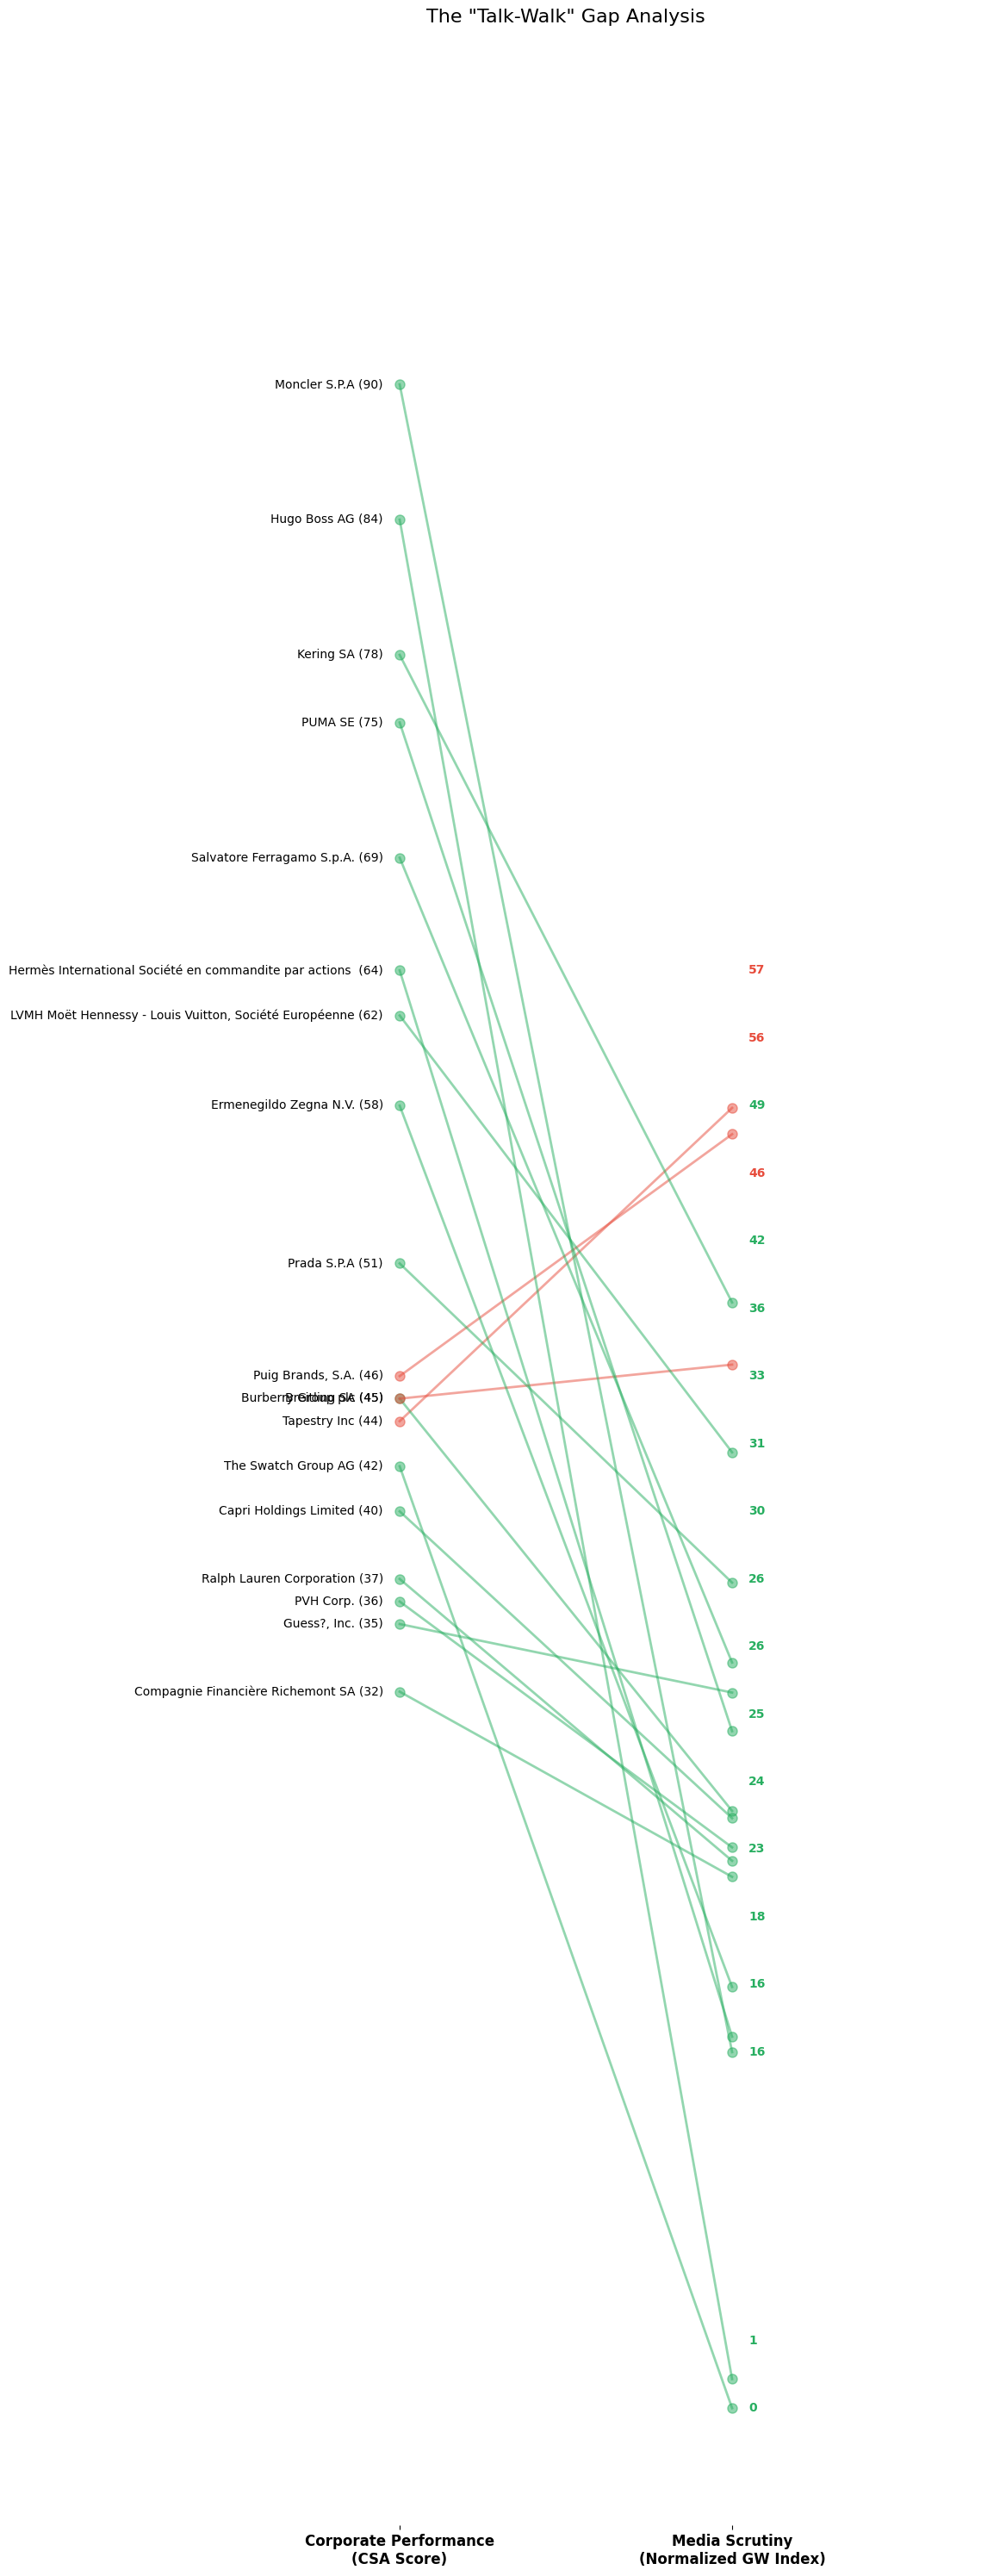

In [ ]:
# Creating a slope chart to compare CSA scores with Normalized Greenwashing Index for the luxury brands

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(12, 30))
plt.xlim(-0.8, 1.8)
plt.ylim(-5, 105)

# Sorting the dataframe by CSA Score so the drawing order is cleaner
df_sorted = df_all.sort_values('CSA Score', ascending=True).reset_index(drop=True)

# Filtering out rows with NaN values for CSA Score or Normalized_GW before plotting
df_plot = df_sorted.dropna(subset=['CSA Score', 'Normalized_GW'])

right_labels_data = []

for i, row in df_plot.iterrows():
    color = '#E74C3C' if row['Normalized_GW'] > row['CSA Score'] else '#27AE60'

    plt.plot([0, 1], [row['CSA Score'], row['Normalized_GW']], marker='o', color=color, alpha=0.5, linewidth=2, markersize=8)

    csa_score_str = str(int(row['CSA Score']))
    plt.text(-0.05, row['CSA Score'],
             f"{row['Brand Name']} ({csa_score_str})",
             ha='right', va='center', fontsize=10, fontweight='500')

    right_labels_data.append({
        'brand_name': row['Brand Name'],
        'normalized_gw': row['Normalized_GW'],
        'csa_score': row['CSA Score'], # Keep csa_score for color determination
        'color': color
    })

right_labels_data_sorted = sorted(right_labels_data, key=lambda x: x['normalized_gw'])

placed_right_y_coords = []
min_spacing = 3.0

for item in right_labels_data_sorted:
    normalized_gw_str = str(int(item['normalized_gw']))
    target_y = item['normalized_gw']
    color = item['color']

    adjusted_y = target_y
    max_attempts = 500
    attempt_count = 0

    while attempt_count < max_attempts:
        overlap_found_in_this_pass = False
        for placed_y in placed_right_y_coords:
            if abs(adjusted_y - placed_y) < min_spacing:
                overlap_found_in_this_pass = True
                adjusted_y = placed_y + min_spacing
                break
        if not overlap_found_in_this_pass:
            break

        attempt_count += 1

    adjusted_y = max(plt.ylim()[0], min(plt.ylim()[1], adjusted_y))

    placed_right_y_coords.append(adjusted_y)

    plt.text(1.05, adjusted_y,
             f"{normalized_gw_str}",
             ha='left', va='center', fontsize=10, fontweight='bold', color=color)

plt.xticks([0, 1], ['Corporate Performance\n(CSA Score)', 'Media Scrutiny\n(Normalized GW Index)'], fontsize=12, fontweight='bold')
plt.title('The "Talk-Walk" Gap Analysis', fontsize=16, pad=20)

sns.despine(left=True, bottom=True)
plt.yticks([])
plt.tight_layout()
plt.savefig('Chart3_Slope_Clean.png', dpi=300)
plt.show()

In [ ]:
from scipy.stats import pearsonr, spearmanr

# Filter out rows with NaN values in 'CSA Score' or 'Greenwashing Ratio'
df_corr = df_all.dropna(subset=['CSA Score', 'Greenwashing Ratio'])

r_p, p_p = pearsonr(df_corr['CSA Score'], df_corr['Greenwashing Ratio'])
r_s, p_s = spearmanr(df_corr['CSA Score'], df_corr['Greenwashing Ratio'])

print(f"--- CORRELATION ANALYSIS ---")
print(f"Pearson (Linear Relationship): r = {r_p:.3f}, p = {p_p:.3f}")
print(f"Spearman (Rank Relationship): rho = {r_s:.3f}, p = {p_s:.3f}")
print("----------------------------\n")

--- CORRELATION ANALYSIS ---
Pearson (Linear Relationship): r = -0.166, p = 0.497
Spearman (Rank Relationship): rho = -0.026, p = 0.915
----------------------------

